# Deep Dive: Translog Patterns — Converted vs Cancelled Reservations

**Objective:** Identify event-level patterns in the HLES Translog that differentiate reservations that converted into rentals from those that were cancelled.

**Data Sources:**
- `Conversion Data Nov-Dec 2025 (1).xlsx` — 68,360 reservations with outcome labels
- `Translog (Partitioned) Nov-Dec 2025.csv` — ~8.8M transaction log events

**Scope:** Contacted reservations only (excludes No-Contact group). Unused reservations excluded.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Hertz brand palette
HERTZ_YELLOW = '#F5C400'
CHARCOAL = '#1A1A1A'
DARK_GRAY = '#6E6E6E'
LIGHT_GRAY = '#E6E6E6'
POS_GREEN = '#2E7D32'
NEG_RED = '#C62828'
TERTIARY_GRAY = '#BDBDBD'

def hertz_style(ax, title, subtitle=None):
    """Apply Hertz brand styling to a matplotlib axis."""
    ax.set_facecolor('white')
    ax.figure.set_facecolor('white')
    if subtitle:
        ax.set_title(f'{title}\n{subtitle}', fontsize=13, fontweight='normal',
                     color=CHARCOAL, loc='left', pad=10)
        # Bold only the first line via the title text object
        title_obj = ax.title
        title_obj.set_fontweight('normal')
        # Use fig.text approach instead for clean two-line title
        ax.set_title('', pad=0)
        ax.text(0, 1.08, title, transform=ax.transAxes,
                fontsize=13, fontweight='bold', color=CHARCOAL, va='bottom')
        ax.text(0, 1.02, subtitle, transform=ax.transAxes,
                fontsize=10, fontweight='normal', color=DARK_GRAY, va='bottom')
    else:
        ax.set_title(title, fontsize=13, fontweight='bold', color=CHARCOAL, loc='left', pad=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color(LIGHT_GRAY)
    ax.yaxis.grid(True, color=LIGHT_GRAY, linewidth=0.7)
    ax.xaxis.grid(False)
    ax.tick_params(colors=DARK_GRAY, labelsize=9)
    ax.set_axisbelow(True)

print('Setup complete.')

Setup complete.


## 1. Load & Prepare Data

In [2]:
# Load Conversion Data
conv_df = pd.read_excel('../data/raw/Conversion Data Nov-Dec 2025 (1).xlsx', engine='openpyxl')
conv_df.columns = conv_df.columns.str.strip().str.replace('\n', '')

# Label outcomes
conv_df['status'] = np.where(conv_df['RENT_IND'] == 1, 'Converted',
                    np.where(conv_df['CANCEL_ID'] == 1, 'Cancelled', 'Unused'))

print(f'Conversion Data: {conv_df.shape[0]:,} reservations')
print(conv_df['status'].value_counts())

Conversion Data: 68,360 reservations
status
Converted    41371
Cancelled    13688
Unused       13301
Name: count, dtype: int64


In [3]:
# Load Translog — filter to matching reservations only
all_confirm_nums = set(conv_df['CONFIRM_NUM'].astype(str).tolist())

chunks = []
for chunk in pd.read_csv('../data/raw/Translog (Partitioned) Nov-Dec 2025.csv',
                          chunksize=500_000, low_memory=False):
    chunk['REZ_NUM'] = chunk['REZ_NUM'].astype(str)
    filtered = chunk[chunk['REZ_NUM'].isin(all_confirm_nums)]
    if len(filtered) > 0:
        chunks.append(filtered)

translog_df = pd.concat(chunks, ignore_index=True)
print(f'Filtered Translog: {translog_df.shape[0]:,} events')
print(f'Matching reservations: {translog_df["REZ_NUM"].nunique():,} / {len(all_confirm_nums):,}')

Filtered Translog: 404,508 events
Matching reservations: 61,560 / 68,360


In [4]:
# Join datasets
translog_df['CONFIRM_NUM_JOIN'] = translog_df['REZ_NUM'].astype(str)
conv_df['CONFIRM_NUM_JOIN'] = conv_df['CONFIRM_NUM'].astype(str)

translog_df = translog_df.merge(
    conv_df[['CONFIRM_NUM_JOIN', 'status', 'CONTACT_GROUP', 'CANCEL REASON']],
    on='CONFIRM_NUM_JOIN', how='left'
)

# Flag contact group
translog_df['is_no_contact'] = translog_df['CONTACT_GROUP'].str.contains(
    'No Contact|NO CONTACT', case=False, na=False)

# Focus: Contacted + (Converted or Cancelled)
df = translog_df[(~translog_df['is_no_contact']) &
                 (translog_df['status'].isin(['Converted', 'Cancelled']))].copy()

# Combine message fields for keyword search
df['all_msgs'] = (
    df['MSG1'].fillna('') + ' ' +
    df['MSG2'].fillna('') + ' ' +
    df['MSG3'].fillna('') + ' ' +
    df['MSG10'].fillna('')
).str.upper()

N_CANCELLED = df[df['status'] == 'Cancelled']['CONFIRM_NUM_JOIN'].nunique()
N_CONVERTED = df[df['status'] == 'Converted']['CONFIRM_NUM_JOIN'].nunique()

print(f'\nAnalysis dataset: {len(df):,} events')
print(f'  Cancelled reservations: {N_CANCELLED:,}')
print(f'  Converted reservations: {N_CONVERTED:,}')
print(f'  Conversion rate (contacted): {N_CONVERTED / (N_CANCELLED + N_CONVERTED) * 100:.1f}%')


Analysis dataset: 340,614 events
  Cancelled reservations: 9,332
  Converted reservations: 38,526
  Conversion rate (contacted): 80.5%


---
## 2. Event Volume: Converted Reservations Are Far More Active

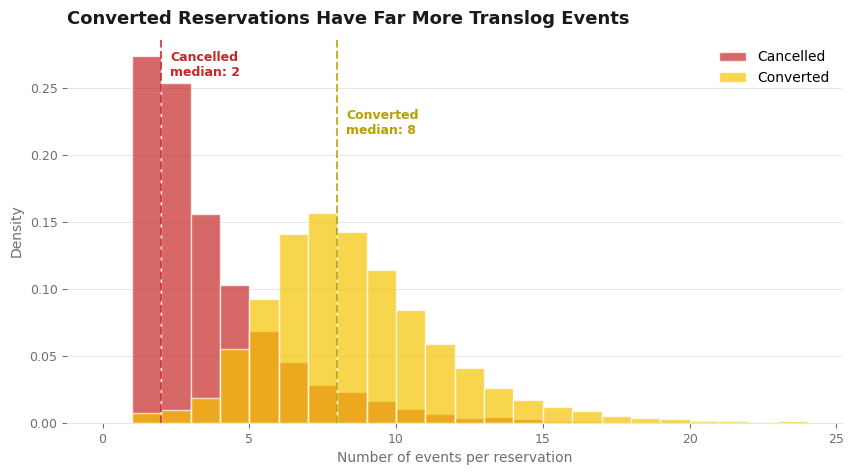


Summary statistics:
             count  mean  std  min  25%  50%   75%   max
status                                                  
Cancelled   9332.0   3.2  2.7  1.0  1.0  2.0   4.0  39.0
Converted  38526.0   8.1  3.2  1.0  6.0  8.0  10.0  62.0


In [5]:
events_per_res = df.groupby(['CONFIRM_NUM_JOIN', 'status']).size().reset_index(name='event_count')

fig, ax = plt.subplots(figsize=(10, 5))

bins = range(0, 25)
for status, color, label in [('Cancelled', NEG_RED, 'Cancelled'),
                              ('Converted', HERTZ_YELLOW, 'Converted')]:
    data = events_per_res[events_per_res['status'] == status]['event_count']
    ax.hist(data, bins=bins, density=True, alpha=0.7, color=color, label=label, edgecolor='white')

hertz_style(ax, 'Converted Reservations Have Far More Translog Events')
ax.set_xlabel('Number of events per reservation', color=DARK_GRAY)
ax.set_ylabel('Density', color=DARK_GRAY)
ax.legend(frameon=False, loc='upper right')

# Add median annotations
med_canc = events_per_res[events_per_res['status'] == 'Cancelled']['event_count'].median()
med_conv = events_per_res[events_per_res['status'] == 'Converted']['event_count'].median()
ax.axvline(med_canc, color=NEG_RED, linestyle='--', linewidth=1.5, alpha=0.8)
ax.axvline(med_conv, color='#B8A000', linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(med_canc + 0.3, ax.get_ylim()[1] * 0.9, f'Cancelled\nmedian: {med_canc:.0f}',
        fontsize=9, color=NEG_RED, fontweight='bold')
ax.text(med_conv + 0.3, ax.get_ylim()[1] * 0.75, f'Converted\nmedian: {med_conv:.0f}',
        fontsize=9, color='#B8A000', fontweight='bold')

fig.subplots_adjust(top=0.88)
plt.show()

print('\nSummary statistics:')
print(events_per_res.groupby('status')['event_count'].describe().round(1))

---
## 3. Early Warning Signals: Patterns More Common in Cancelled Reservations

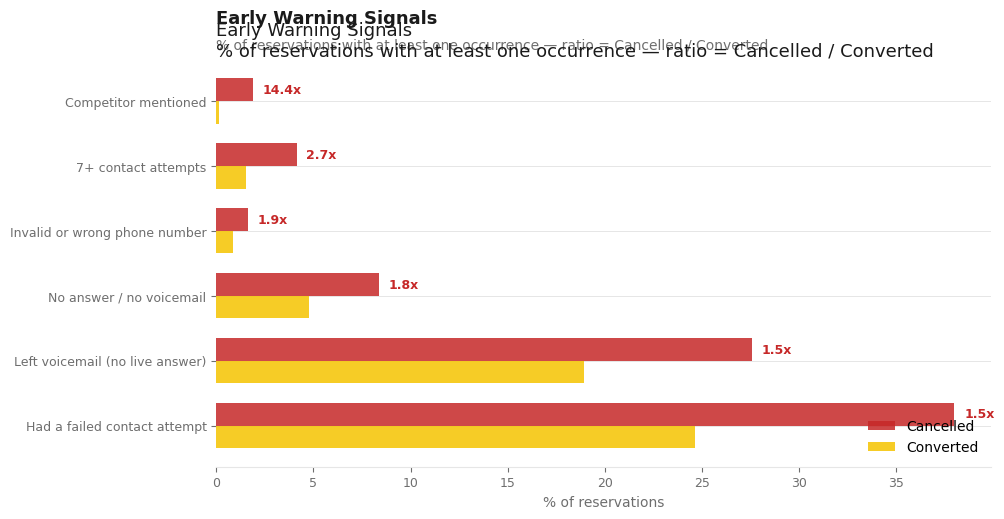

                        Pattern  Cancelled  Converted  Ratio
   Had a failed contact attempt       38.0       24.7    1.5
Left voicemail (no live answer)       27.6       18.9    1.5
       No answer / no voicemail        8.4        4.8    1.8
  Invalid or wrong phone number        1.6        0.9    1.9
            7+ contact attempts        4.1        1.5    2.7
           Competitor mentioned        1.9        0.1   14.4


In [6]:
def pct_reservations(condition_func, status):
    """Return % of reservations (for a given status) with at least one event matching condition."""
    subset = df[df['status'] == status]
    matched = subset[condition_func(subset)]
    total = N_CANCELLED if status == 'Cancelled' else N_CONVERTED
    return matched['CONFIRM_NUM_JOIN'].nunique() / total * 100

# Define warning signals
warning_signals = [
    ('Had a failed contact attempt',
     lambda d: d['MSG1'] == 'Loc-Failed Contact Attempt'),
    ('Left voicemail (no live answer)',
     lambda d: d['MSG2'].str.contains('Left Vm|UCC10', case=False, na=False)),
    ('No answer / no voicemail',
     lambda d: d['MSG2'].str.contains('UCC8-No answer', case=False, na=False)),
    ('Invalid or wrong phone number',
     lambda d: d['MSG2'].str.contains('Not a valid phone|Wrong Number|UCC2|UCC4', case=False, na=False)),
    ('Competitor mentioned',
     lambda d: d['all_msgs'].str.contains('COMPETITOR|ENTERPRISE|AVIS|BUDGET|NATIONAL|ALAMO', na=False)),
]

warning_data = []
for name, cond in warning_signals:
    canc = pct_reservations(cond, 'Cancelled')
    conv = pct_reservations(cond, 'Converted')
    warning_data.append({'Pattern': name, 'Cancelled': canc, 'Converted': conv})

# Add 7+ contact attempts (computed differently)
contact_counts = df[df['MSG1'].str.contains('Contact', case=False, na=False)].groupby(
    ['CONFIRM_NUM_JOIN', 'status']).size().reset_index(name='n')
canc_7plus = contact_counts[(contact_counts['status'] == 'Cancelled') & (contact_counts['n'] >= 7)]['CONFIRM_NUM_JOIN'].nunique()
conv_7plus = contact_counts[(contact_counts['status'] == 'Converted') & (contact_counts['n'] >= 7)]['CONFIRM_NUM_JOIN'].nunique()
warning_data.append({'Pattern': '7+ contact attempts',
                      'Cancelled': canc_7plus / N_CANCELLED * 100,
                      'Converted': conv_7plus / N_CONVERTED * 100})

warnings_df = pd.DataFrame(warning_data)
warnings_df['Ratio'] = (warnings_df['Cancelled'] / warnings_df['Converted']).round(1)
warnings_df = warnings_df.sort_values('Ratio', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 5.5))
y = range(len(warnings_df))
bar_height = 0.35

ax.barh([i + bar_height/2 for i in y], warnings_df['Cancelled'], bar_height,
        color=NEG_RED, label='Cancelled', alpha=0.85)
ax.barh([i - bar_height/2 for i in y], warnings_df['Converted'], bar_height,
        color=HERTZ_YELLOW, label='Converted', alpha=0.85)

ax.set_yticks(y)
ax.set_yticklabels(warnings_df['Pattern'])

# Add ratio labels
for i, (_, row) in enumerate(warnings_df.iterrows()):
    ax.text(row['Cancelled'] + 0.5, i + bar_height/2, f"{row['Ratio']}x",
            va='center', fontsize=9, fontweight='bold', color=NEG_RED)

hertz_style(ax, 'Early Warning Signals',
            subtitle='% of reservations with at least one occurrence — ratio = Cancelled / Converted')
ax.set_xlabel('% of reservations', color=DARK_GRAY)
ax.legend(frameon=False, loc='lower right', bbox_to_anchor=(1.0, 0.0))
fig.subplots_adjust(top=0.85)
plt.show()

print(warnings_df[['Pattern', 'Cancelled', 'Converted', 'Ratio']].to_string(index=False, float_format='%.1f'))

---
## 4. Success Indicators: Patterns More Common in Converted Reservations

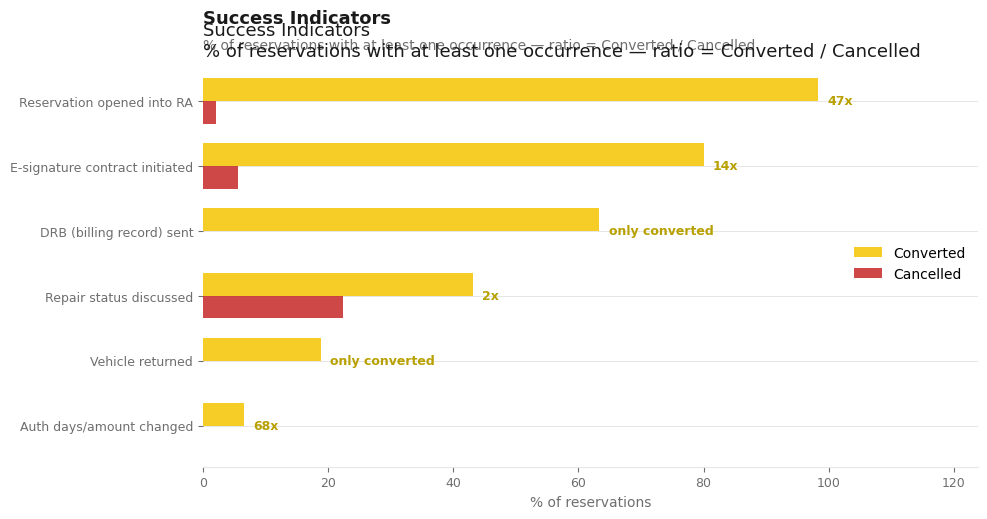

                       Pattern  Cancelled  Converted  Ratio
      Auth days/amount changed        0.1        6.6   68.5
              Vehicle returned        0.0       18.9    inf
       Repair status discussed       22.4       43.1    1.9
     DRB (billing record) sent        0.0       63.4    inf
E-signature contract initiated        5.6       80.0   14.3
    Reservation opened into RA        2.1       98.3   46.8


In [7]:
success_signals = [
    ('Reservation opened into RA',
     lambda d: d['MSG1'] == 'Rez-Reservation Opened Into RA'),
    ('E-signature contract initiated',
     lambda d: d['MSG1'] == 'RA-eSignerMSR Interface'),
    ('DRB (billing record) sent',
     lambda d: d['MSG1'] == 'R/A-DRB Sent'),
    ('Vehicle returned',
     lambda d: d['MSG1'] == 'R/A-Returned'),
    ('Repair status discussed',
     lambda d: d['all_msgs'].str.contains('REPAIR|BODY SHOP|STILL IN SHOP', na=False)),
    ('Auth days/amount changed',
     lambda d: d['MSG1'].str.contains('Changed Auth', case=False, na=False)),
]

success_data = []
for name, cond in success_signals:
    canc = pct_reservations(cond, 'Cancelled')
    conv = pct_reservations(cond, 'Converted')
    success_data.append({'Pattern': name, 'Cancelled': canc, 'Converted': conv})

success_df = pd.DataFrame(success_data)
success_df['Ratio'] = np.where(success_df['Cancelled'] > 0,
                                (success_df['Converted'] / success_df['Cancelled']).round(1),
                                np.inf)
success_df = success_df.sort_values('Converted', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 5.5))
y = range(len(success_df))
bar_height = 0.35

ax.barh([i + bar_height/2 for i in y], success_df['Converted'], bar_height,
        color=HERTZ_YELLOW, label='Converted', alpha=0.85)
ax.barh([i - bar_height/2 for i in y], success_df['Cancelled'], bar_height,
        color=NEG_RED, label='Cancelled', alpha=0.85)

ax.set_yticks(y)
ax.set_yticklabels(success_df['Pattern'])

# Add ratio labels — offset to the right of the longer bar
for i, (_, row) in enumerate(success_df.iterrows()):
    ratio_text = f"{row['Ratio']:.0f}x" if row['Ratio'] != np.inf else 'only converted'
    max_val = max(row['Converted'], row['Cancelled'])
    ax.text(max_val + 1.5, i, ratio_text,
            va='center', fontsize=9, fontweight='bold', color='#B8A000')

hertz_style(ax, 'Success Indicators',
            subtitle='% of reservations with at least one occurrence — ratio = Converted / Cancelled')
ax.set_xlabel('% of reservations', color=DARK_GRAY)
# Add right margin for ratio labels
ax.set_xlim(right=ax.get_xlim()[1] * 1.2)
ax.legend(frameon=False, loc='center right')
fig.subplots_adjust(top=0.85)
plt.show()

print(success_df[['Pattern', 'Cancelled', 'Converted', 'Ratio']].to_string(index=False, float_format='%.1f'))

---
## 5. Contact Quality > Quantity

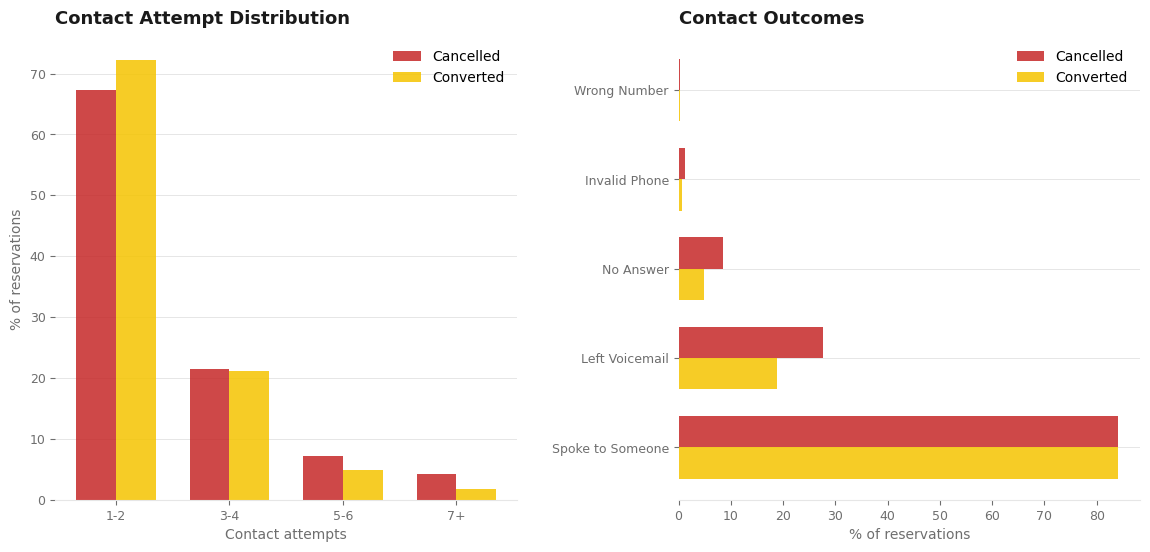

In [8]:
# Contact attempts per reservation
contact_attempts = df[df['MSG1'].str.contains('Contact', case=False, na=False)].groupby(
    ['CONFIRM_NUM_JOIN', 'status']).size().reset_index(name='contact_attempts')

def bucket_attempts(n):
    if n <= 2: return '1-2'
    elif n <= 4: return '3-4'
    elif n <= 6: return '5-6'
    else: return '7+'

contact_attempts['bucket'] = contact_attempts['contact_attempts'].apply(bucket_attempts)
crosstab = pd.crosstab(contact_attempts['bucket'], contact_attempts['status'], normalize='columns') * 100
crosstab = crosstab.reindex(['1-2', '3-4', '5-6', '7+'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: distribution of contact attempt buckets
ax = axes[0]
x = range(len(crosstab))
bar_width = 0.35
ax.bar([i - bar_width/2 for i in x], crosstab['Cancelled'], bar_width,
       color=NEG_RED, label='Cancelled', alpha=0.85)
ax.bar([i + bar_width/2 for i in x], crosstab['Converted'], bar_width,
       color=HERTZ_YELLOW, label='Converted', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(crosstab.index)
ax.set_xlabel('Contact attempts', color=DARK_GRAY)
ax.set_ylabel('% of reservations', color=DARK_GRAY)
hertz_style(ax, 'Contact Attempt Distribution')
ax.legend(frameon=False, loc='upper right')

# Right: contact outcomes
ax = axes[1]
contact_events = df[df['MSG1'].str.contains('Contact', case=False, na=False)].copy()

def categorize_contact(msg2):
    if pd.isna(msg2): return 'Other'
    msg2 = str(msg2).upper()
    if 'LEFT VM' in msg2 or 'UCC10' in msg2: return 'Left Voicemail'
    elif 'NO ANSWER' in msg2 or 'UCC8' in msg2: return 'No Answer'
    elif 'NOT A VALID' in msg2 or 'UCC2' in msg2: return 'Invalid Phone'
    elif 'WRONG NUMBER' in msg2 or 'UCC4' in msg2: return 'Wrong Number'
    elif 'SPOKE TO' in msg2: return 'Spoke to Someone'
    return 'Other'

contact_events['outcome'] = contact_events['MSG2'].apply(categorize_contact)

# % of reservations with at least one occurrence of each outcome
outcomes_list = ['Spoke to Someone', 'Left Voicemail', 'No Answer', 'Invalid Phone', 'Wrong Number']
outcome_data = []
for outcome in outcomes_list:
    for status in ['Cancelled', 'Converted']:
        subset = contact_events[(contact_events['status'] == status) & (contact_events['outcome'] == outcome)]
        total = N_CANCELLED if status == 'Cancelled' else N_CONVERTED
        pct = subset['CONFIRM_NUM_JOIN'].nunique() / total * 100
        outcome_data.append({'Outcome': outcome, 'Status': status, 'Pct': pct})

outcome_df = pd.DataFrame(outcome_data)
outcome_pivot = outcome_df.pivot(index='Outcome', columns='Status', values='Pct')
outcome_pivot = outcome_pivot.reindex(outcomes_list)

y = range(len(outcome_pivot))
ax.barh([i + 0.175 for i in y], outcome_pivot['Cancelled'], 0.35,
        color=NEG_RED, label='Cancelled', alpha=0.85)
ax.barh([i - 0.175 for i in y], outcome_pivot['Converted'], 0.35,
        color=HERTZ_YELLOW, label='Converted', alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(outcome_pivot.index)
ax.set_xlabel('% of reservations', color=DARK_GRAY)
hertz_style(ax, 'Contact Outcomes')
ax.legend(frameon=False, loc='upper right')

fig.subplots_adjust(top=0.88, wspace=0.35)
plt.show()

---
## 6. Cancellation Reasons Breakdown

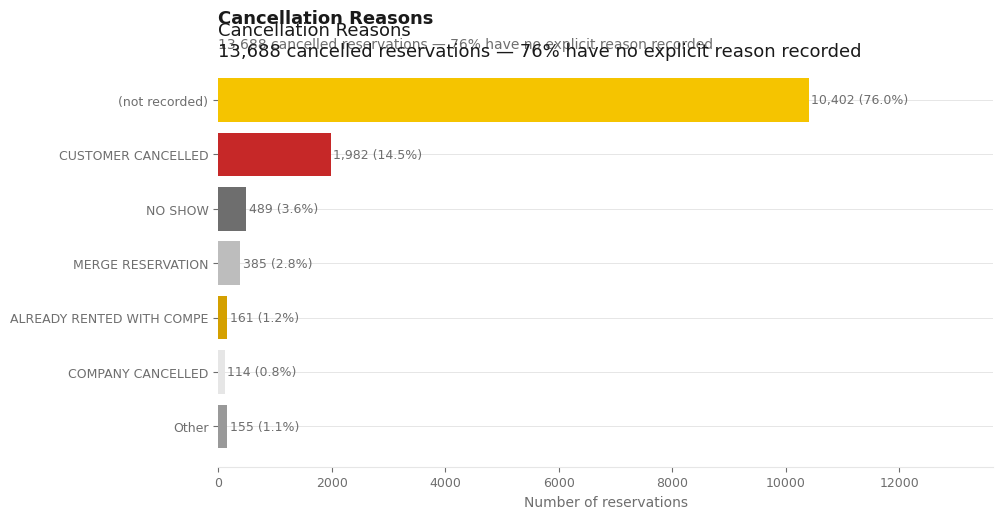

In [9]:
# From conversion data
cancelled_conv = conv_df[conv_df['status'] == 'Cancelled'].copy()
cancel_reasons = cancelled_conv['CANCEL REASON'].fillna('(not recorded)').str.strip()
cancel_reasons = cancel_reasons.replace('', '(not recorded)')
reason_counts = cancel_reasons.value_counts()

# Group small categories
top_reasons = reason_counts.head(6)
other = reason_counts.iloc[6:].sum()
if other > 0:
    top_reasons['Other'] = other

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = [HERTZ_YELLOW, NEG_RED, DARK_GRAY, TERTIARY_GRAY, '#D4A000', LIGHT_GRAY, '#999999']
bars = ax.barh(range(len(top_reasons)), top_reasons.values, color=colors[:len(top_reasons)])
ax.set_yticks(range(len(top_reasons)))
ax.set_yticklabels(top_reasons.index)
ax.invert_yaxis()

# Add count labels
for i, val in enumerate(top_reasons.values):
    pct = val / reason_counts.sum() * 100
    ax.text(val + 50, i, f'{val:,} ({pct:.1f}%)', va='center', fontsize=9, color=DARK_GRAY)

hertz_style(ax, 'Cancellation Reasons',
            subtitle=f'{reason_counts.sum():,} cancelled reservations — 76% have no explicit reason recorded')
ax.set_xlabel('Number of reservations', color=DARK_GRAY)
# Add right margin for count labels
ax.set_xlim(right=ax.get_xlim()[1] * 1.25)
fig.subplots_adjust(top=0.85)
plt.show()

---
## 7. Events Leading Up to Cancellation

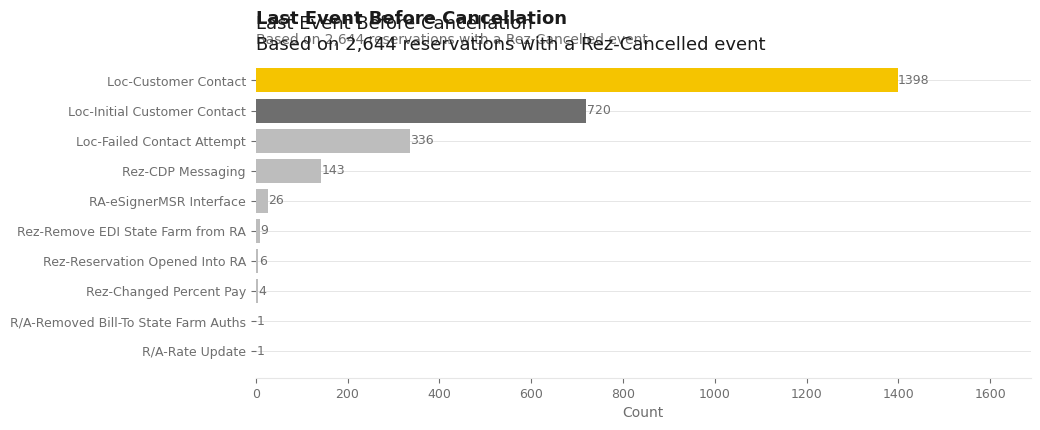

In [10]:
# Parse dates for sequencing
df['parsed_date'] = pd.to_datetime(df['SystemDate'].astype(str), format='%Y%m%d%H%M%S', errors='coerce')

# For cancelled reservations with a Rez-Cancelled event, find the event immediately before
cancelled_events = df[df['status'] == 'Cancelled'].sort_values(['CONFIRM_NUM_JOIN', 'parsed_date'])
cancelled_res_ids = cancelled_events[cancelled_events['MSG1'] == 'Rez-Cancelled']['CONFIRM_NUM_JOIN'].unique()

events_before_cancel = []
for res_id in cancelled_res_ids:
    group = cancelled_events[cancelled_events['CONFIRM_NUM_JOIN'] == res_id]
    cancel_mask = group['MSG1'] == 'Rez-Cancelled'
    if cancel_mask.any():
        cancel_idx = group[cancel_mask].index[0]
        before = group.loc[:cancel_idx]
        if len(before) > 1:
            events_before_cancel.append(before.iloc[-2:-1])

if events_before_cancel:
    before_df = pd.concat(events_before_cancel)
    last_event = before_df['MSG1'].value_counts()

    fig, ax = plt.subplots(figsize=(10, 4.5))
    colors_list = [HERTZ_YELLOW if i == 0 else DARK_GRAY if i == 1 else TERTIARY_GRAY for i in range(len(last_event))]
    bars = ax.barh(range(len(last_event)), last_event.values, color=colors_list)
    ax.set_yticks(range(len(last_event)))
    ax.set_yticklabels(last_event.index)
    ax.invert_yaxis()

    for i, val in enumerate(last_event.values):
        ax.text(val + 1, i, str(val), va='center', fontsize=9, color=DARK_GRAY)

    hertz_style(ax, 'Last Event Before Cancellation',
                subtitle=f'Based on {len(before_df):,} reservations with a Rez-Cancelled event')
    ax.set_xlabel('Count', color=DARK_GRAY)
    ax.set_xlim(right=ax.get_xlim()[1] * 1.15)
    fig.subplots_adjust(top=0.83)
    plt.show()

---
## 8. Hypothesis Test: Do Non-Converted Reservations Have More Back-and-Forth Changes?

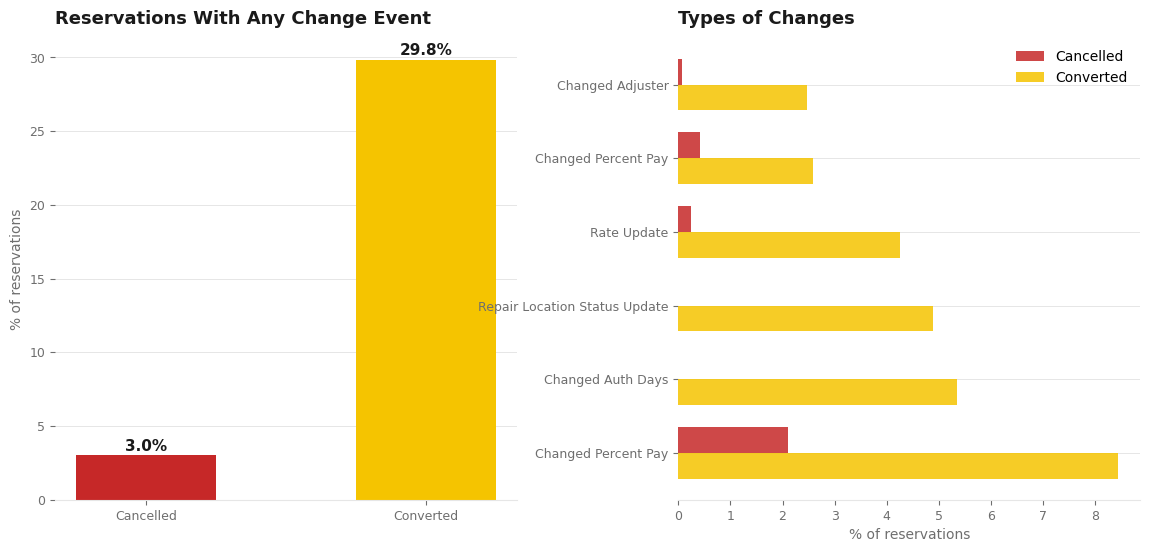


HYPOTHESIS REJECTED: Converted reservations have MORE changes, not fewer.
  Cancelled with changes: 3.0% of reservations
  Converted with changes: 29.8% of reservations
  Changes indicate ENGAGEMENT with the rental process, not problems.


In [11]:
# Identify change-related events
change_events = df[df['MSG1'].str.contains('Chang|Updat|Modif', case=False, na=False)]

# % of reservations with at least one change
canc_with_changes = change_events[change_events['status'] == 'Cancelled']['CONFIRM_NUM_JOIN'].nunique()
conv_with_changes = change_events[change_events['status'] == 'Converted']['CONFIRM_NUM_JOIN'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: % with any change
ax = axes[0]
vals = [canc_with_changes / N_CANCELLED * 100, conv_with_changes / N_CONVERTED * 100]
bars = ax.bar(['Cancelled', 'Converted'], vals, color=[NEG_RED, HERTZ_YELLOW], width=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold', color=CHARCOAL)
hertz_style(ax, 'Reservations With Any Change Event')
ax.set_ylabel('% of reservations', color=DARK_GRAY)

# Right: type of changes
ax = axes[1]
change_types = change_events.groupby(['status', 'MSG1']).agg(
    res_count=('CONFIRM_NUM_JOIN', 'nunique')
).reset_index()

# Normalize
change_types['pct'] = change_types.apply(
    lambda r: r['res_count'] / (N_CANCELLED if r['status'] == 'Cancelled' else N_CONVERTED) * 100, axis=1)

# Top change types in converted
top_changes = change_types[change_types['status'] == 'Converted'].nlargest(6, 'pct')['MSG1'].tolist()

plot_data = change_types[change_types['MSG1'].isin(top_changes)].pivot(
    index='MSG1', columns='status', values='pct').fillna(0)
plot_data = plot_data.reindex(top_changes)

y = range(len(plot_data))
ax.barh([i + 0.175 for i in y], plot_data.get('Cancelled', [0]*len(plot_data)), 0.35,
        color=NEG_RED, label='Cancelled', alpha=0.85)
ax.barh([i - 0.175 for i in y], plot_data.get('Converted', [0]*len(plot_data)), 0.35,
        color=HERTZ_YELLOW, label='Converted', alpha=0.85)
ax.set_yticks(y)
# Shorten labels
short_labels = [l.replace('R/A-', '').replace('Rez-', '').replace('Edi-', '').replace(' (Utility Page)', '')
                for l in plot_data.index]
ax.set_yticklabels(short_labels)
ax.set_xlabel('% of reservations', color=DARK_GRAY)
hertz_style(ax, 'Types of Changes')
ax.legend(frameon=False, loc='upper right')

fig.subplots_adjust(top=0.88, wspace=0.35)
plt.show()

print('\nHYPOTHESIS REJECTED: Converted reservations have MORE changes, not fewer.')
print(f'  Cancelled with changes: {canc_with_changes / N_CANCELLED * 100:.1f}% of reservations')
print(f'  Converted with changes: {conv_with_changes / N_CONVERTED * 100:.1f}% of reservations')
print('  Changes indicate ENGAGEMENT with the rental process, not problems.')

---
## 9. Key Takeaways

### Early Warning Signals (predict cancellation risk)
| Pattern | Cancelled | Converted | Ratio |
|---------|-----------|-----------|-------|
| Had a failed contact attempt | 38.0% | 24.7% | 1.5x |
| Left voicemail (no live answer) | 27.6% | 18.9% | 1.5x |
| No answer / no voicemail | 8.4% | 4.8% | 1.8x |
| Invalid or wrong phone number | 1.6% | 0.9% | 1.9x |
| 7+ contact attempts | 4.1% | 1.5% | 2.7x |
| Competitor mentioned | 1.9% | 0.1% | 14.4x |

### Core Insight: Contact Quality > Quantity
Cancelled reservations actually receive **more** contact attempts on average (2.4 vs 2.1), but they have significantly more **failed** contacts. The issue isn't lack of effort — it's contact success rate.

### Hypothesis Result: Back-and-Forth Changes
**REJECTED.** Converted reservations have more change events. Changes to authorization days, percent pay, rates, etc. indicate active engagement with the rental process — a positive signal, not a warning sign.

### Actionable Recommendations
1. **Phone number validation** at reservation creation to reduce invalid-number contacts
2. **Alternative contact channels** (text, email) when phone contact fails on first attempt
3. **Early intervention flag** when a reservation accumulates 2+ failed contact attempts
4. **Competitor-risk monitoring** for any mention of competitor names in contact notes